In [1]:
pip install pandas matplotlib seaborn numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define file paths
file_paths = {
    "gpt-3.5-turbo": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/gpt-3.5-turbo.csv",
    "gpt-4-turbo": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/gpt-4-turbo.csv",
    "allam-2-7b": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/allam-2-7b.csv",
    "llama-3.3-70b-versatile": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/llama-3.3-70b-versatile.csv",
    "deepseek-r1-distill-llama-70b": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/deepseek-r1-distill-llama-70b.csv"
}

# Load the data
evaluation_data = {}
for model, path in file_paths.items():
    evaluation_data[model] = pd.read_csv(path)

# Preview a sample dataset
for model, df in evaluation_data.items():
    print(f"📌 Sample Data from {model}:\n", df.head(), "\n")
    break  # Print only one model's data for preview

📌 Sample Data from gpt-3.5-turbo:
    index                                               text  \
0      0  in the end we all die, nothing we do means any...   
1      1  Today would have been my best friend's 18th bi...   
2      2  So I couldn't feel any worse, and I've had eno...   
3      3  I am 22 and have never had a girlfriend and ha...   
4      4  I am almost certain that my depression is caus...   

                                     original_reason  \
0  feel more and more empty,fear lonliness,get ti...   
1   best friend's birthday, he's gone, never supp...   
2  absolute minimal contact with,  be more direct...   
3   never had a girlfriend, rejected countless times   
4  eating out with family, what after that? Paren...   

                                    generated_reason  original_reason_score  \
0  The person seems to be experiencing alienation...                     85   
1  The emotional distress, grief, and longing exp...                     90   
2  The perso

# Summary Statistics (Mean, Median, Standard Deviation)

In [15]:
import pandas as pd

# Compute summary statistics for each model
summary_data = []

for model, df in evaluation_data.items():
    summary_data.append([
        model, 
        df["original_reason_score"].mean(), df["original_reason_score"].median(), df["original_reason_score"].std(),
        df["generated_reason_score"].mean(), df["generated_reason_score"].median(), df["generated_reason_score"].std()
    ])

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data, columns=["Model", "Original Mean", "Original Median", "Original Std Dev",
                                                 "Generated Mean", "Generated Median", "Generated Std Dev"])

# Display summary statistics
print(summary_df)

# Optionally, save to CSV
summary_df.to_csv("summary_statistics.csv", index=False)


                           Model  Original Mean  Original Median  \
0                  gpt-3.5-turbo      83.372767             90.0   
1                    gpt-4-turbo      35.662723             40.0   
2                     allam-2-7b      76.056253             80.0   
3        llama-3.3-70b-versatile      38.684935             40.0   
4  deepseek-r1-distill-llama-70b      59.181555             60.0   

   Original Std Dev  Generated Mean  Generated Median  Generated Std Dev  
0         11.081708       92.084017              95.0           5.752371  
1         20.685580       82.069049              85.0          12.481991  
2         13.910171       84.648479              90.0           9.636100  
3         17.412186       87.136957              90.0           8.175878  
4         21.378905       84.092950              85.0          10.689389  


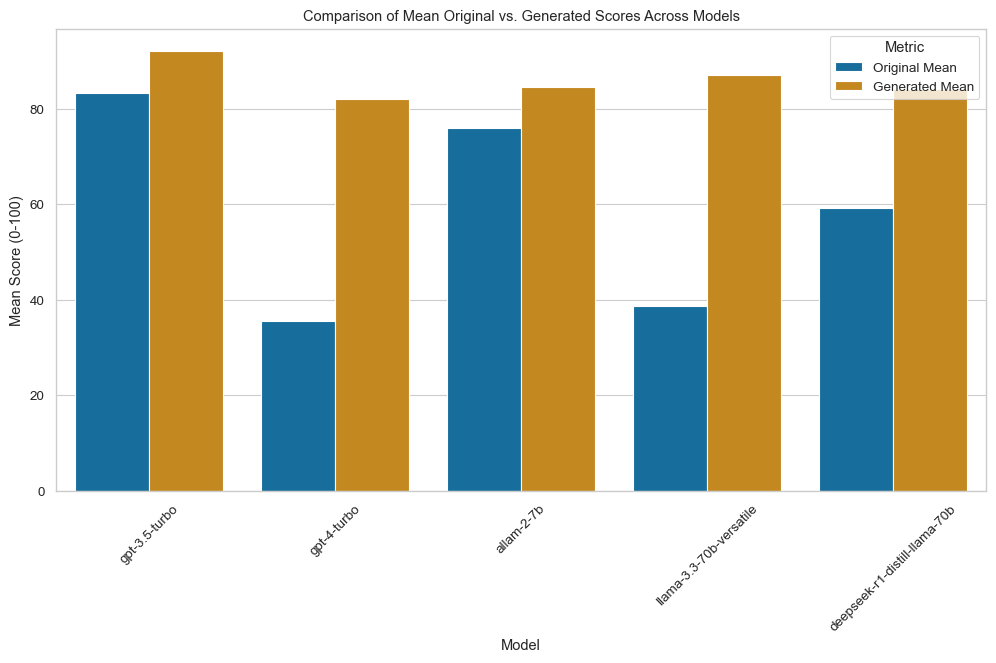

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Convert summary statistics into a long-form dataframe for plotting
summary_long = summary_df.melt(id_vars=["Model"], var_name="Metric", value_name="Score")

# Filter for only mean values
summary_filtered = summary_long[summary_long["Metric"].str.contains("Mean")]

# Create bar chart
sns.barplot(x="Model", y="Score", hue="Metric", data=summary_filtered)
plt.ylabel("Mean Score (0-100)")
plt.title("Comparison of Mean Original vs. Generated Scores Across Models")
plt.xticks(rotation=45)
plt.show()


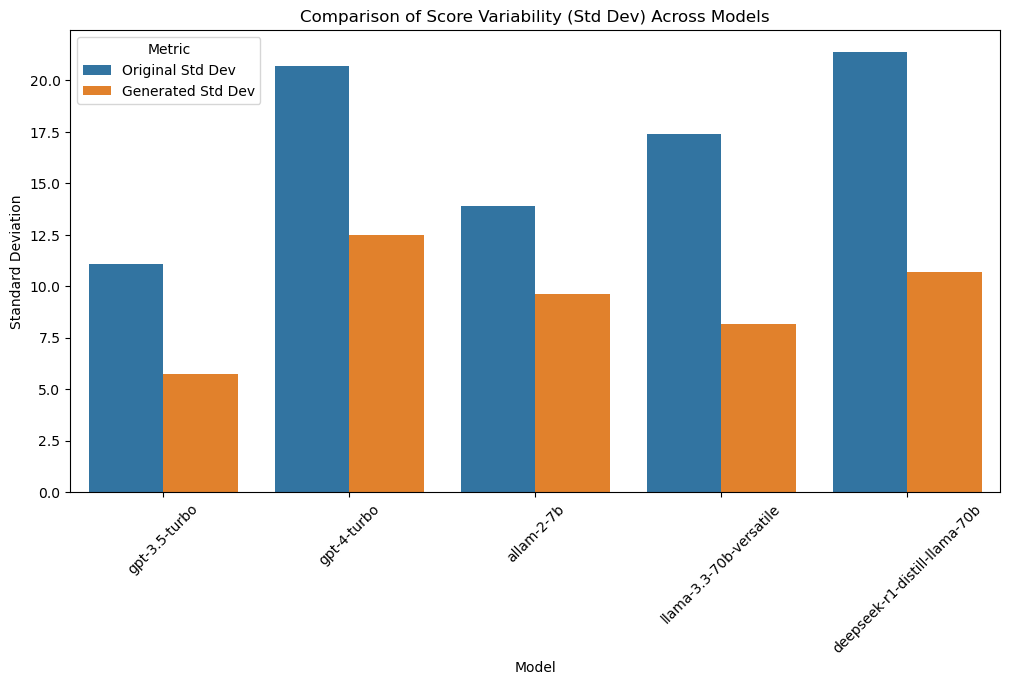

In [9]:
plt.figure(figsize=(12, 6))

# Filter for standard deviation values
std_filtered = summary_long[summary_long["Metric"].str.contains("Std Dev")]

# Create bar chart
sns.barplot(x="Model", y="Score", hue="Metric", data=std_filtered)
plt.ylabel("Standard Deviation")
plt.title("Comparison of Score Variability (Std Dev) Across Models")
plt.xticks(rotation=45)
plt.show()


# Score Improvement Analysis (Score Difference & Percentage Improvement)

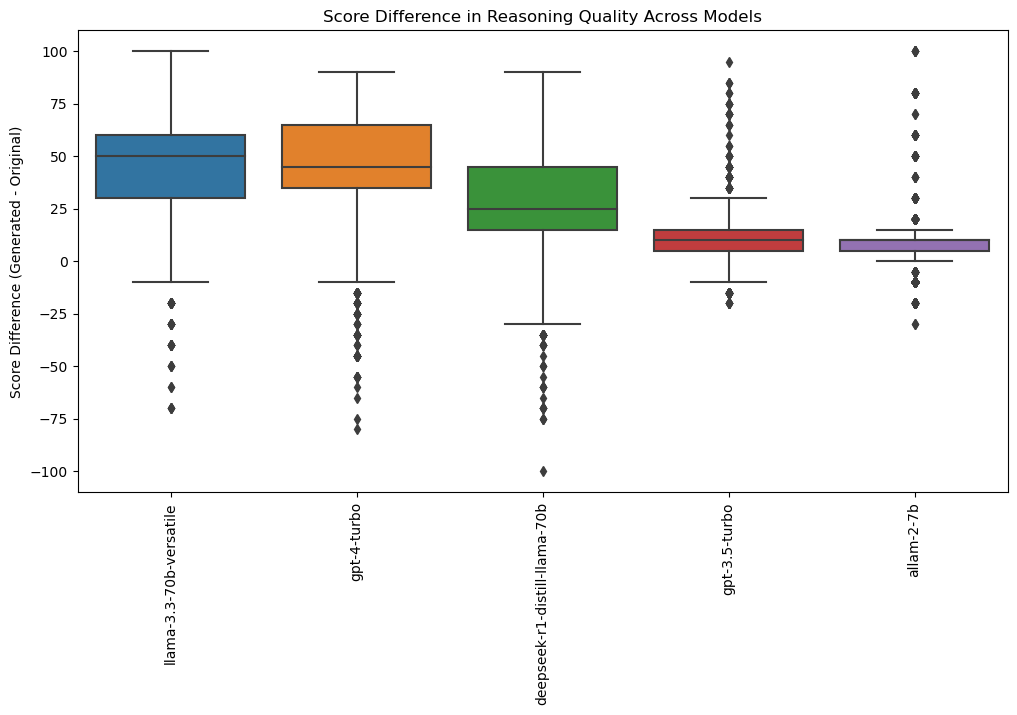

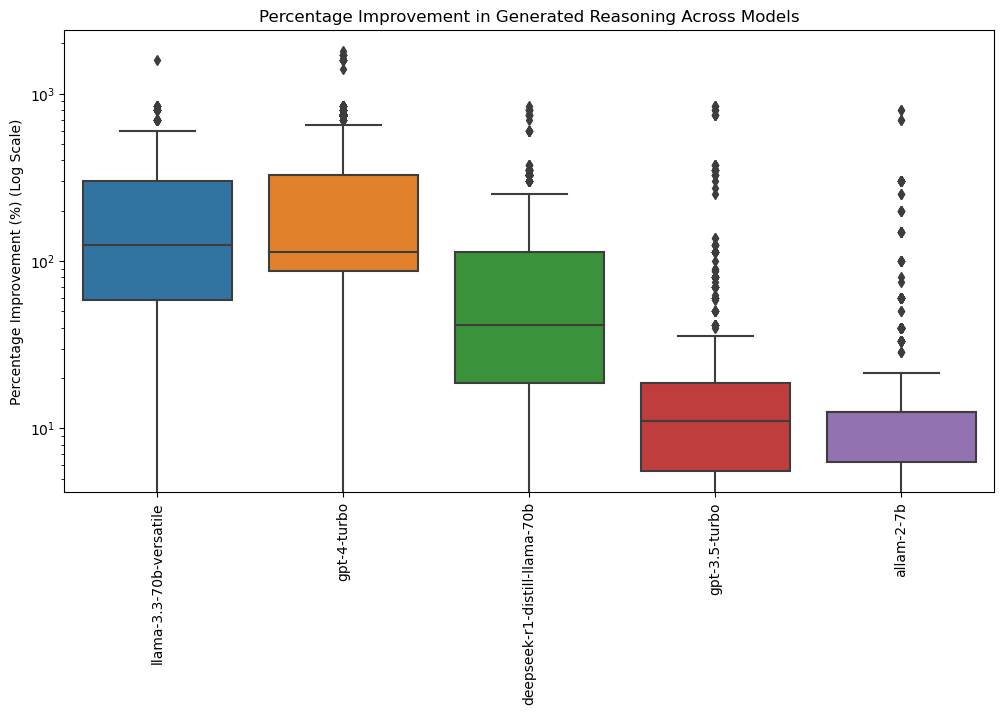

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
score_diffs = []
percentage_improvements = []
labels = []

for model, df in evaluation_data.items():
    improvement = df["generated_reason_score"] - df["original_reason_score"]
    percentage_improvement = ((df["generated_reason_score"] - df["original_reason_score"]) / df["original_reason_score"]) * 100

    score_diffs.append(improvement)
    percentage_improvements.append(percentage_improvement)
    labels.append(model)

# Convert to DataFrame
improvement_df = pd.DataFrame(score_diffs).T
improvement_df.columns = labels

percentage_df = pd.DataFrame(percentage_improvements).T
percentage_df.columns = labels

# Sort by median improvement
sorted_models = improvement_df.median().sort_values(ascending=False).index
improvement_df = improvement_df[sorted_models]
percentage_df = percentage_df[sorted_models]

# Create Score Difference Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=improvement_df)
plt.xticks(rotation=90)
plt.ylabel("Score Difference (Generated - Original)")
plt.title("Score Difference in Reasoning Quality Across Models")
plt.show()

# Create Percentage Improvement Boxplot with Log Scale
plt.figure(figsize=(12, 6))
sns.boxplot(data=percentage_df)
plt.yscale("log")  # Use logarithmic scale for better visualization
plt.xticks(rotation=90)
plt.ylabel("Percentage Improvement (%) (Log Scale)")
plt.title("Percentage Improvement in Generated Reasoning Across Models")
plt.show()


# Statistical Significance Testing (Wilcoxon Signed-Rank Test and Paired t-Test)

In [27]:
from scipy.stats import ttest_rel, wilcoxon
import numpy as np
import pandas as pd

# Store results
stat_results = []

for model, df in evaluation_data.items():
    df = df.dropna(subset=["original_reason_score", "generated_reason_score"])  # Remove NaNs
    
    if model == "llama-3.3-70b-versatile":  
        # Run Paired t-Test (because this model passed the normality test)
        t_stat, p_value = ttest_rel(df["original_reason_score"], df["generated_reason_score"])
        stat_results.append([model, "t-Test", t_stat, p_value])
    
    else:
        # Run Wilcoxon Signed-Rank Test (for models that failed normality test)
        w_stat, p_value = wilcoxon(df["generated_reason_score"], df["original_reason_score"])
        stat_results.append([model, "Wilcoxon Signed-Rank", w_stat, p_value])

# Convert to DataFrame
stat_df = pd.DataFrame(stat_results, columns=["Model", "Test Used", "Statistic", "P-Value"])

# Display results
print(stat_df)

# Save to CSV (optional)
stat_df.to_csv("statistical_tests_results.csv", index=False)


                           Model             Test Used     Statistic  P-Value
0                  gpt-3.5-turbo  Wilcoxon Signed-Rank  8.021235e+05      0.0
1                    gpt-4-turbo  Wilcoxon Signed-Rank  1.307530e+05      0.0
2                     allam-2-7b  Wilcoxon Signed-Rank  1.039255e+06      0.0
3        llama-3.3-70b-versatile                t-Test -1.647313e+02      0.0
4  deepseek-r1-distill-llama-70b  Wilcoxon Signed-Rank  5.988030e+05      0.0


# Effect Size (Cohen’s d) Analysis

In [17]:
import numpy as np

# Function to compute Cohen's d
def cohens_d(x, y):
    diff = np.mean(y) - np.mean(x)
    pooled_std = np.sqrt((np.std(x, ddof=1) ** 2 + np.std(y, ddof=1) ** 2) / 2)
    return diff / pooled_std

# Compute Cohen’s d for each model
cohens_d_results = []

for model, df in evaluation_data.items():
    d_value = cohens_d(df["original_reason_score"], df["generated_reason_score"])
    cohens_d_results.append([model, d_value])

# Convert to DataFrame
cohens_d_df = pd.DataFrame(cohens_d_results, columns=["Model", "Cohen's d"])

# Display Cohen's d results
print(cohens_d_df)

# Save to CSV (optional)
cohens_d_df.to_csv("cohens_d_effect_size.csv", index=False)


                           Model  Cohen's d
0                  gpt-3.5-turbo   0.986690
1                    gpt-4-turbo   2.716438
2                     allam-2-7b   0.718082
3        llama-3.3-70b-versatile   3.562123
4  deepseek-r1-distill-llama-70b   1.473917


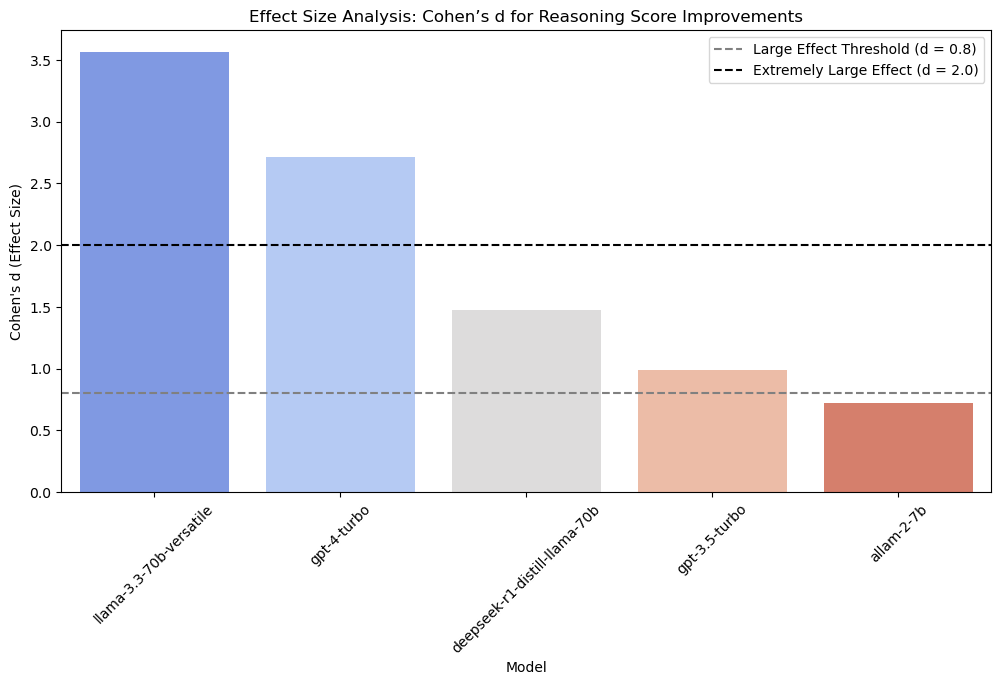

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Sort by effect size
cohens_d_df = cohens_d_df.sort_values(by="Cohen's d", ascending=False)

# Create bar chart
sns.barplot(x="Model", y="Cohen's d", data=cohens_d_df, palette="coolwarm")
plt.axhline(y=0.8, color="gray", linestyle="--", label="Large Effect Threshold (d = 0.8)")
plt.axhline(y=2.0, color="black", linestyle="--", label="Extremely Large Effect (d = 2.0)")
plt.ylabel("Cohen's d (Effect Size)")
plt.title("Effect Size Analysis: Cohen’s d for Reasoning Score Improvements")
plt.xticks(rotation=45)
plt.legend()
plt.show()


# Pearson & Spearman Correlation

In [20]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

correlation_results = []

for model, df in evaluation_data.items():
    # Drop rows with NaN values
    df = df.dropna(subset=["original_reason_score", "generated_reason_score"])
    
    # Remove infinite values (if any)
    df = df[np.isfinite(df["original_reason_score"]) & np.isfinite(df["generated_reason_score"])]
    
    # Ensure there is variation in the scores (avoid all values being the same)
    if df["original_reason_score"].nunique() <= 1 or df["generated_reason_score"].nunique() <= 1:
        pearson_corr, pearson_p, spearman_corr, spearman_p = np.nan, np.nan, np.nan, np.nan
    else:
        pearson_corr, pearson_p = pearsonr(df["original_reason_score"], df["generated_reason_score"])
        spearman_corr, spearman_p = spearmanr(df["original_reason_score"], df["generated_reason_score"])

    correlation_results.append([model, pearson_corr, pearson_p, spearman_corr, spearman_p])

# Convert to DataFrame
correlation_df = pd.DataFrame(correlation_results, columns=["Model", "Pearson Correlation", "Pearson P-Value",
                                                            "Spearman Correlation", "Spearman P-Value"])

# Display correlation results
print(correlation_df)

# Save to CSV (optional)
correlation_df.to_csv("correlation_results_fixed.csv", index=False)


                           Model  Pearson Correlation  Pearson P-Value  \
0                  gpt-3.5-turbo             0.353261    5.169223e-122   
1                    gpt-4-turbo             0.008039     6.049876e-01   
2                     allam-2-7b             0.550641     0.000000e+00   
3        llama-3.3-70b-versatile             0.042171     6.652468e-03   
4  deepseek-r1-distill-llama-70b             0.095976     6.043890e-10   

   Spearman Correlation  Spearman P-Value  
0              0.509498     1.568436e-272  
1              0.187103      6.069610e-34  
2              0.596475      0.000000e+00  
3              0.217576      1.503803e-45  
4              0.273994      3.141978e-72  


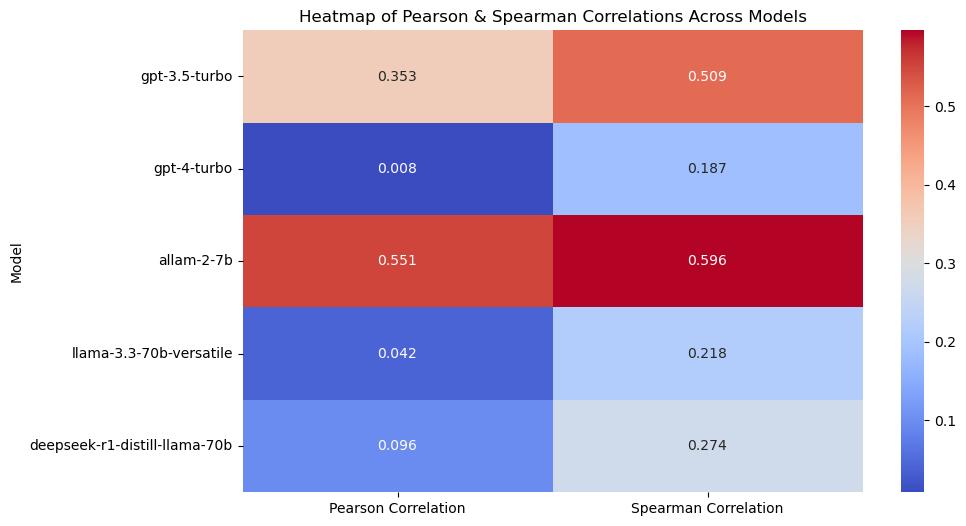

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Convert correlation results to a DataFrame
correlation_matrix = correlation_df.set_index("Model")[["Pearson Correlation", "Spearman Correlation"]]

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Heatmap of Pearson & Spearman Correlations Across Models")
plt.show()


# Confidence Interval for Mean Difference

In [23]:
import numpy as np

confidence_results = []

for model, df in evaluation_data.items():
    mean_diff = np.mean(df["generated_reason_score"] - df["original_reason_score"])
    std_err = np.std(df["generated_reason_score"] - df["original_reason_score"], ddof=1) / np.sqrt(len(df))
    ci_low, ci_high = mean_diff - 1.96 * std_err, mean_diff + 1.96 * std_err
    confidence_results.append([model, mean_diff, ci_low, ci_high])

# Convert to DataFrame
confidence_df = pd.DataFrame(confidence_results, columns=["Model", "Mean Difference", "CI Lower Bound", "CI Upper Bound"])
print(confidence_df)


                           Model  Mean Difference  CI Lower Bound  \
0                  gpt-3.5-turbo         8.711251        8.390601   
1                    gpt-4-turbo        46.406325       45.673174   
2                     allam-2-7b         8.592226        8.233520   
3        llama-3.3-70b-versatile        48.452657       47.876298   
4  deepseek-r1-distill-llama-70b        24.911395       24.211967   

   CI Upper Bound  
0        9.031900  
1       47.139476  
2        8.950932  
3       49.029016  
4       25.610824  


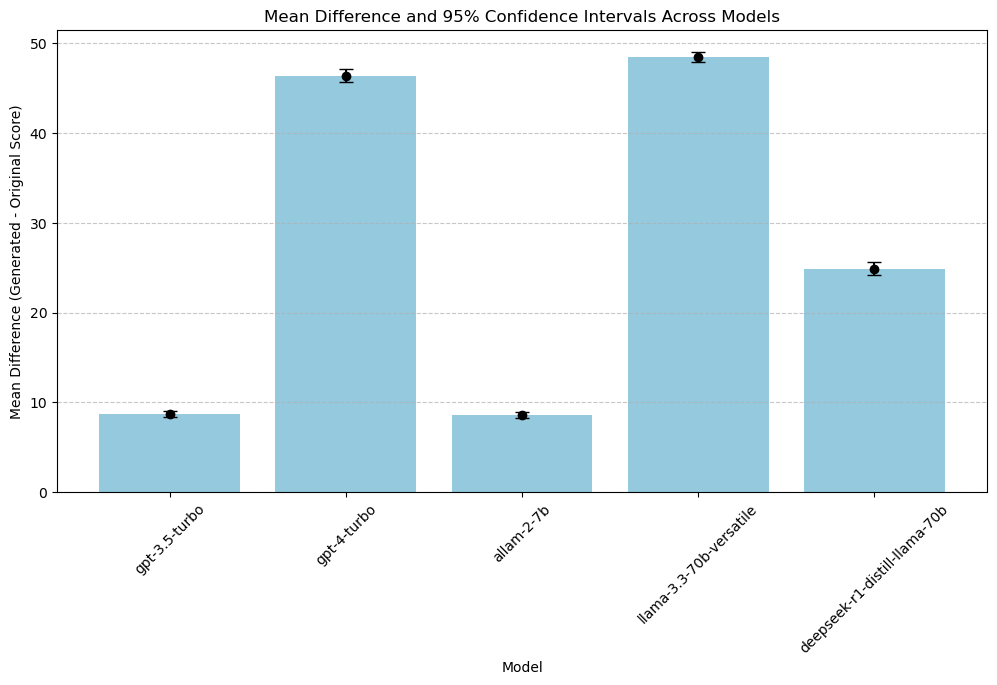

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Plot Mean Differences with Error Bars
sns.barplot(x="Model", y="Mean Difference", data=confidence_df, ci=None, color="skyblue")
plt.errorbar(confidence_df["Model"], confidence_df["Mean Difference"],
             yerr=[confidence_df["Mean Difference"] - confidence_df["CI Lower Bound"],
                   confidence_df["CI Upper Bound"] - confidence_df["Mean Difference"]],
             fmt="o", color="black", capsize=5)

plt.ylabel("Mean Difference (Generated - Original Score)")
plt.title("Mean Difference and 95% Confidence Intervals Across Models")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


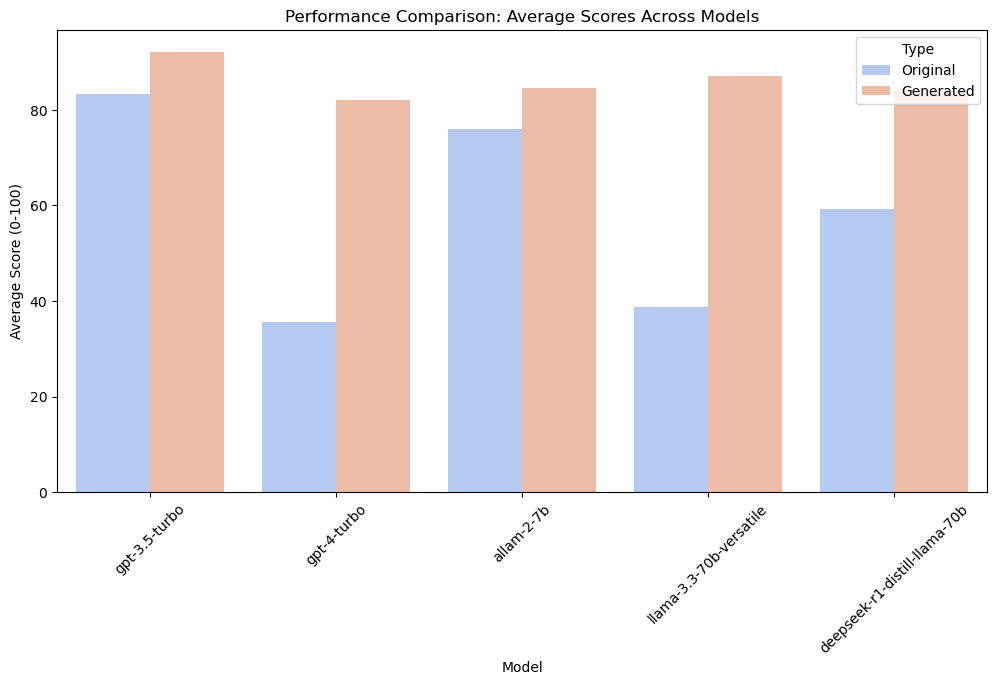

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(12, 6))

# Prepare data for visualization
avg_scores = []

for model, df in evaluation_data.items():
    avg_scores.append([model, "Original", df["original_reason_score"].mean()])
    avg_scores.append([model, "Generated", df["generated_reason_score"].mean()])

avg_df = pd.DataFrame(avg_scores, columns=["Model", "Type", "Average Score"])

# Create bar chart
sns.barplot(x="Model", y="Average Score", hue="Type", data=avg_df, palette="coolwarm")
plt.ylabel("Average Score (0-100)")
plt.title("Performance Comparison: Average Scores Across Models")
plt.xticks(rotation=45)
plt.show()


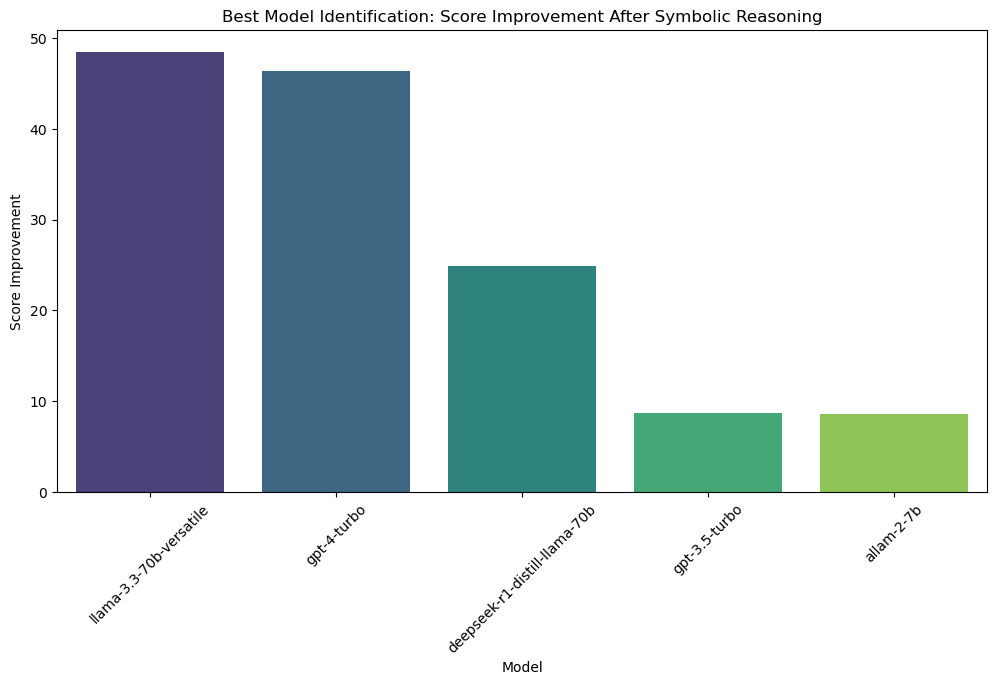

In [30]:
plt.figure(figsize=(12, 6))

# Compute improvements
improvements = []
for model, df in evaluation_data.items():
    avg_original = df["original_reason_score"].mean()
    avg_generated = df["generated_reason_score"].mean()
    improvement = avg_generated - avg_original
    improvements.append([model, improvement])

improvement_df = pd.DataFrame(improvements, columns=["Model", "Score Improvement"])
improvement_df = improvement_df.sort_values(by="Score Improvement", ascending=False)

# Create bar chart
sns.barplot(x="Model", y="Score Improvement", data=improvement_df, palette="viridis")
plt.ylabel("Score Improvement")
plt.title("Best Model Identification: Score Improvement After Symbolic Reasoning")
plt.xticks(rotation=45)
plt.show()


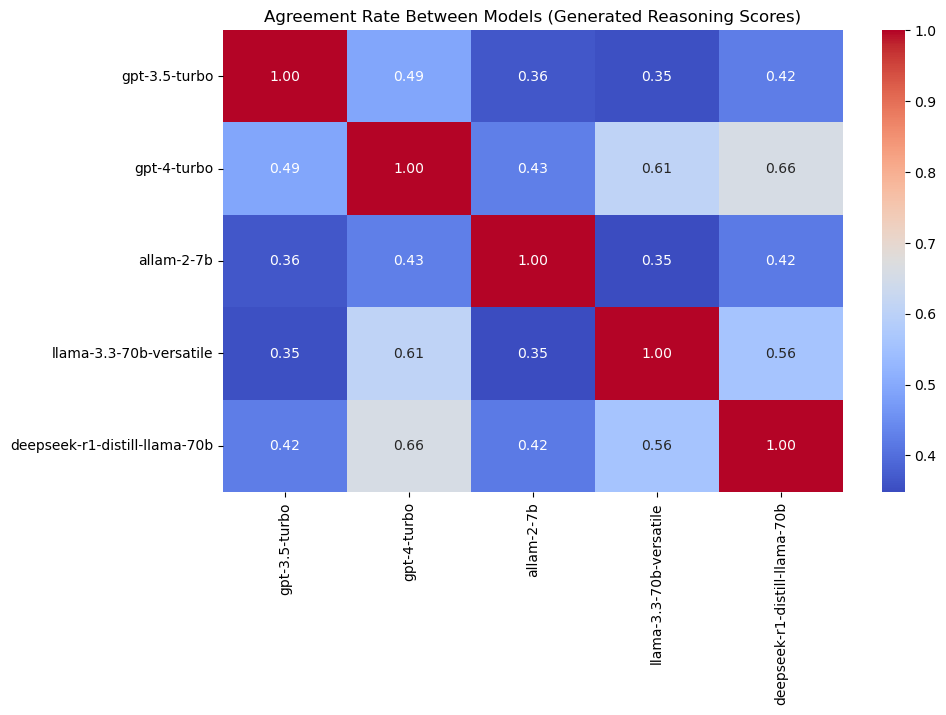

In [31]:
import numpy as np

plt.figure(figsize=(10, 6))

# Compute correlation between models based on generated reason scores
agreement_matrix = {}

for model, df in evaluation_data.items():
    agreement_matrix[model] = df["generated_reason_score"]

agreement_df = pd.DataFrame(agreement_matrix)
corr_matrix = agreement_df.corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Agreement Rate Between Models (Generated Reasoning Scores)")
plt.show()


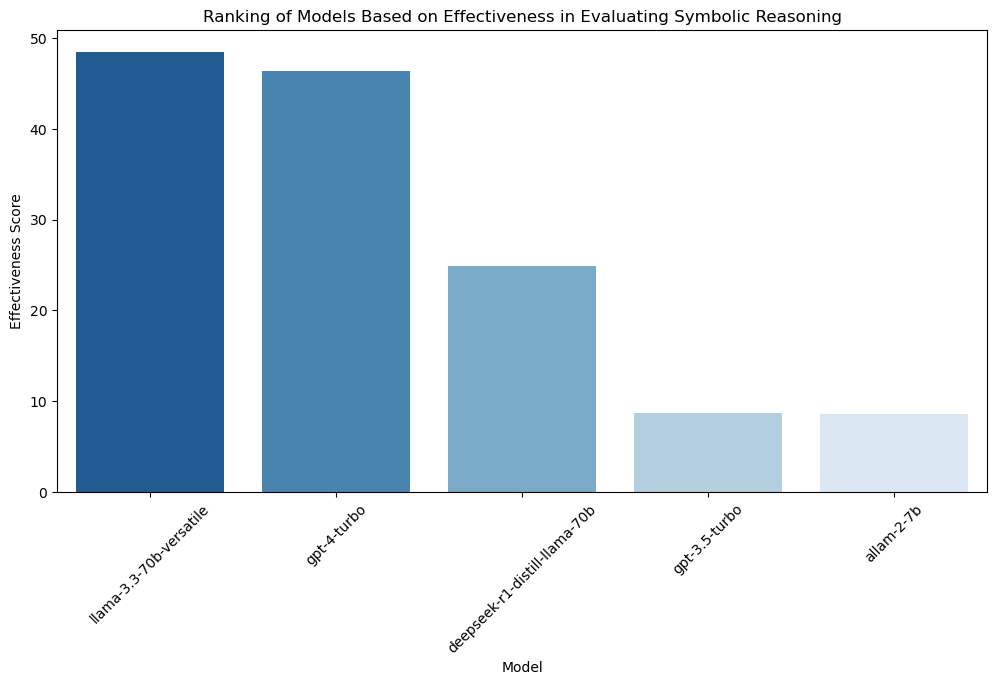

In [32]:
plt.figure(figsize=(12, 6))

# Create ranking based on mean improvement and effect size
ranking_data = []

for model, df in evaluation_data.items():
    mean_improvement = df["generated_reason_score"].mean() - df["original_reason_score"].mean()
    ranking_data.append([model, mean_improvement])

ranking_df = pd.DataFrame(ranking_data, columns=["Model", "Effectiveness Score"])
ranking_df = ranking_df.sort_values(by="Effectiveness Score", ascending=False)

# Create bar chart
sns.barplot(x="Model", y="Effectiveness Score", data=ranking_df, palette="Blues_r")
plt.ylabel("Effectiveness Score")
plt.title("Ranking of Models Based on Effectiveness in Evaluating Symbolic Reasoning")
plt.xticks(rotation=45)
plt.show()
